In [1]:
from qiskit import * 
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.visualization import plot_histogram
import ipywidgets as widgets
from IPython.display import display
from qtree import map_qtree, parse_qtree, draw_qtree
%matplotlib inline

C:\Users\gt_96\AppData\Local\Temp\ipykernel_16108\3300729598.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import *


In [ ]:
# PARAMS

# robot position qbits len
r = 2

# move qbits len
m = 2

# auxiliary qbits len
c = 4

# data qbits len
n = r + m

# target state
# y = ['11']

# solutions len
M = 4

In [3]:
# SIMULAZIONE QASM
def execution(qc, shots=1024):

    backend = AerSimulator()
    qc_compiled = transpile(qc, backend)
    job = backend.run(qc_compiled, shots=shots)
    result = job.result()
    counts = result.get_counts()

    return counts

In [4]:
def move(move_qc):

    # fanout with swap(x,y)
    move_qc.cx(1,3)
    move_qc.cx(0,4)

    # x' <- NOT(CNOT(m,y))
    move_qc.cx(2,3)
    move_qc.x(3)

    # y' <- CNOT(m,x)
    move_qc.cx(2,4)
    
    return move_qc

In [5]:
# ORACLE
def oracle(qc):

    # robot position register
    rr = qc.qregs[0]

    # move register
    mr = qc.qregs[1]

    # auxiliary register
    cr = qc.qregs[2]

    # move operator
    move_qc = move(QuantumCircuit(5))

    # move 1
    qc = qc.compose(move_qc, [rr[0],rr[1],mr[0],cr[0],cr[1]])

    qc.barrier()

    # move 2
    qc = qc.compose(move_qc, [cr[0],cr[1],mr[1],cr[2],cr[3]])
   
    qc.barrier()
    
    # test
    qc.ccx(cr[2], cr[3], n+c)

    qc.barrier()

    # move 2 uncompute
    qc = qc.compose(move_qc.inverse(), [cr[0],cr[1],mr[1],cr[2],cr[3]])

    qc.barrier()
    
    # move 1 uncompute
    qc = qc.compose(move_qc.inverse(), [rr[0],rr[1],mr[0],cr[0],cr[1]])

    qc.barrier()

    return qc

In [6]:
# DIFFUSER
def diffuser(dif_qc):
    
    dif_qc.h(range(n))
    dif_qc.x(range(n))

    dif_qc.barrier(range(n))

    dif_qc.h(n-1)
    dif_qc.mcx(list(range(n-1)), n-1)
    dif_qc.h(n-1)

    dif_qc.barrier(range(n))

    dif_qc.x(range(n))
    dif_qc.h(range(n))

    return dif_qc

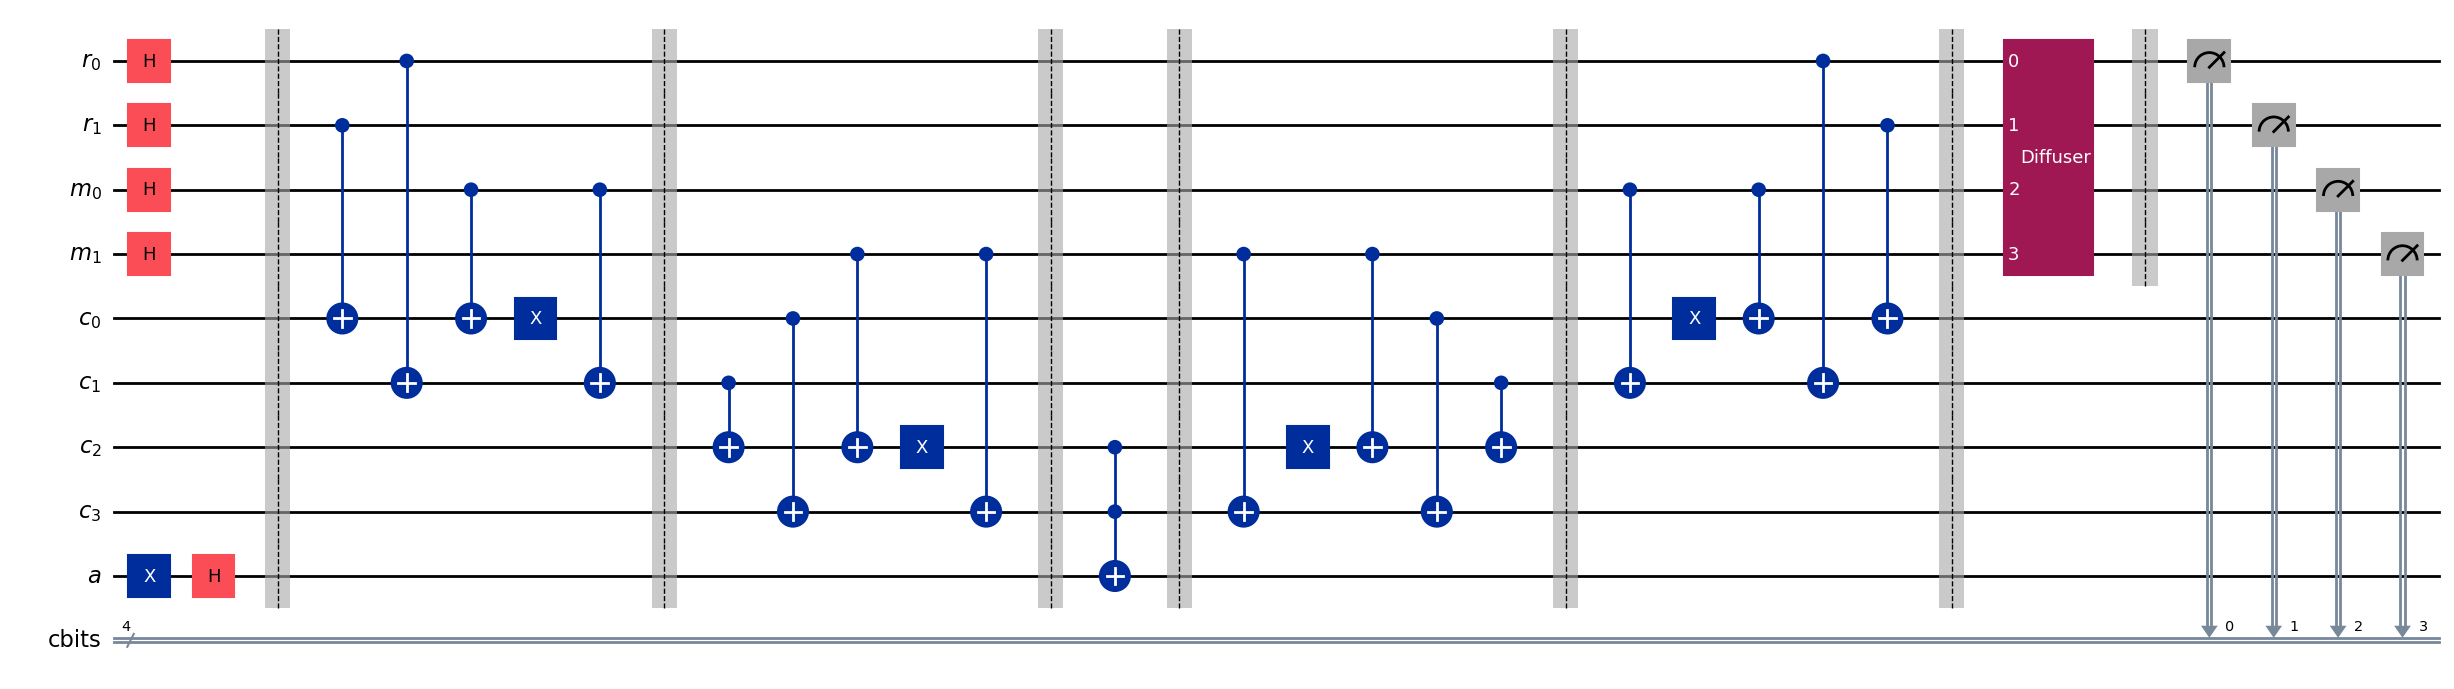

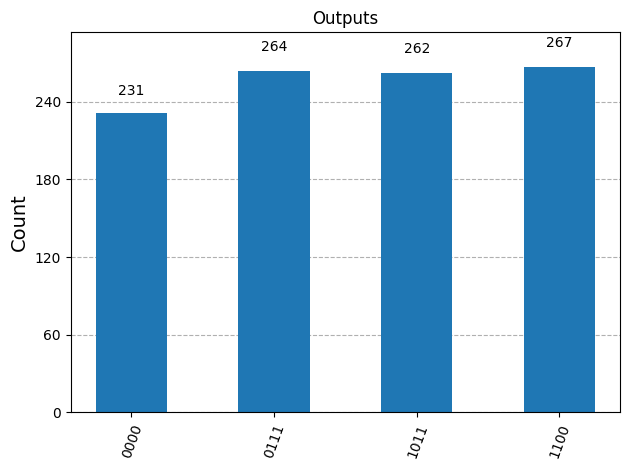

In [7]:
# ROBOT PLANNER
def robot_planner():

    # init
    qc = QuantumCircuit(QuantumRegister(r,'r'),QuantumRegister(m,'m'),QuantumRegister(c,'c'),QuantumRegister(1,'a'),ClassicalRegister(n,'cbits'))

    qc.h(range(n))
    qc.x(n+c)
    qc.h(n+c)

    qc.barrier()

    # optimal iterations
    iterations = int(np.round(np.pi / (4 * np.arcsin(np.sqrt(M / (2**n)))) - 0.5))
    
    # diffuser
    dif_qc = QuantumCircuit(n)
    dif_gate = RemoveBarriers()(diffuser(dif_qc)).to_gate(label='Diffuser')

    # oracle + diffuser iterations
    for _ in range(iterations):
        qc = oracle(qc)
        qc = qc.compose(dif_gate,range(n))
        qc.barrier(range(n))

    # measurement
    qc.measure(range(n), range(n))

    return qc

qc = robot_planner()

counts = execution(qc)

display(qc.draw('mpl', fold=50))

plot_histogram(counts, title='Outputs')

In [8]:
### PROLOG

## QUERY
#
# simple_robot_query(Circuit) :-
#               reset_qbit_number,
#               make_qbits(9,QRin),
#               qrange(2,RQbits), qrange(2,4,MQbits), qrange(4,8,CQbits), A = q(8),
#               nth0(0,RQbits,R0),nth0(1,RQbits,R1),
#               nth0(0,MQbits,M0),nth0(1,MQbits,M1),
#               nth0(0,CQbits,C0),nth0(1,CQbits,C1),nth0(2,CQbits,C2),nth0(CQbits,C3),
#   MOVE_1:     build_circuit(QRin,exp([C0: qNOT (M0 qXOR R1 qXOR C0), C1: M0 qXOR R0 qXOR C1]),QRout),
#   MOVE_2:     complete_circuit(QRin,QRout,exp([C2: qNOT (M1 qXOR C1 qXOR C2), C3: M1 qXOR C0 qXOR C3]),NCircuit1),
#   TEST        complete_circuit(QRin,NCircuit1,exp([A: C2 qAND C3]),NCircuit2),
#   INV_MOVE_2: complete_circuit(QRin,NCircuit2,exp([C2: C1 qXOR M1 qXOR qNOT C2, C3: C0 qXOR M1 qXOR C3]),NCircuit3),
#   INV_MOVE_1: complete_circuit(QRin,NCircuit3,exp([C0: R1 qXOR M0 qXOR qNOT C0, C1: R0 qXOR M0 qXOR C1]),Circuit).

## ANSWER
#
# Circuit =    [
#               
#   MOVE_1:     [q(0):q(0),q(1):q(1),q(2):q(2),q(3):q(3),q(4):[[cnot(q(1),q(4))],[cnot(q(2),q(4))],[not(q(4))]],q(5):[[cnot(q(0),q(5))],[cnot(q(2),q(5))]],q(6):q(6),q(7):q(7),q(8):q(8)],
#   MOVE_2:     [q(0):q(0),q(1):q(1),q(2):q(2),q(3):q(3),q(4):q(4),q(5):q(5),q(6):[[cnot(q(5),q(6))],[cnot(q(3),q(6))],[not(q(6))]],q(7):[[cnot(q(4),q(7))],[cnot(q(3),q(7))]],q(8):q(8)],
#   TEST:       [q(0):q(0),q(1):q(1),q(2):q(2),q(3):q(3),q(4):q(4),q(5):q(5),q(6):q(6),q(7):q(7),q(8):[[tof(q(6),q(7),q(8))]]],
#   INV_MOVE_2: [q(0):q(0),q(1):q(1),q(2):q(2),q(3):q(3),q(4):q(4),q(5):q(5),q(6):[[not(q(6))],[cnot(q(3),q(6))],[cnot(q(5),q(6))]],q(7):[[cnot(q(3),q(7))],[cnot(q(4),q(7))]],q(8):q(8)],
#   INV_MOVE_1: [q(0):q(0),q(1):q(1),q(2):q(2),q(3):q(3),q(4):[[not(q(4))],[cnot(q(2),q(4))],[cnot(q(1),q(4))]],q(5):[[cnot(q(2),q(5))],[cnot(q(0),q(5))]],q(6):q(6),q(7):q(7),q(8):q(8)]
#              
#              ]

## QTREES

# qbit label sostitutions
qtree_map = {
    "q(0)": "r(0)",
    "q(1)": "r(1)",
    "q(2)": "m(0)",
    "q(3)": "m(1)",
    "q(4)": "c(0)",
    "q(5)": "c(1)",
    "q(6)": "c(2)",
    "q(7)": "c(3)",
    "q(8)": "a(0)"
}

# MOVE 1 QTREES
move1_qtree1 = map_qtree('[not(q(4)),[cnot(q(2),q(4)),[q(2)],[cnot(q(1),q(4)),[q(1)],[q(4)]]]]', qtree_map) # target: c(0)
move1_qtree2 = map_qtree('[cnot(q(2),q(5)),[q(2)],[cnot(q(0),q(5)),[q(0)],[q(5)]]]', qtree_map) # target: c(1)

# MOVE 2 QTREES
move2_qtree1 = map_qtree('[not(q(6)),[cnot(q(3),q(6)),[q(3)],[cnot(q(5),q(6)),[q(5)],[q(6)]]]]', qtree_map) # target: c(2)
move2_qtree2 = map_qtree('[cnot(q(3),q(7)),[q(3)],[cnot(q(4),q(7)),[q(4)],[q(7)]]]', qtree_map) # target: c(3)

# TEST QTREE
test_qtree = map_qtree('[tof(q(6),q(7),q(8)),[q(6)],[q(7)]]', qtree_map) # target: a(0)

# INV MOVE 2 QTREES
inv_move2_qtree1 = map_qtree('[cnot(q(4),q(7)),[q(4)],[cnot(q(3),q(7)),[q(3)],[q(7)]]]', qtree_map) # target: c(3)
inv_move2_qtree2 = map_qtree('[cnot(q(5),q(6)),[q(5)],[cnot(q(3),q(6)),[q(3)],[not(q(6)),[q(6)]]]]', qtree_map) # target: c(2)

# INV MOVE 1 QTREES
inv_move1_qtree1 = map_qtree('[cnot(q(0),q(5)),[q(0)],[cnot(q(2),q(5)),[q(2)],[q(5)]]]', qtree_map) # target: c(1)
inv_move1_qtree2 = map_qtree('[cnot(q(1),q(4)),[q(1)],[cnot(q(2),q(4)),[q(2)],[not(q(4)),[q(4)]]]]', qtree_map) # target: c(0)

# VISUALIZATION

mdot11 = draw_qtree(parse_qtree(move1_qtree1), title='Move 1 - c(0) Tree')
mdot12 = draw_qtree(parse_qtree(move1_qtree2), title='Move 1 - c(1) Tree')
mdot21 = draw_qtree(parse_qtree(move2_qtree1), title='Move 2 - c(2) Tree')
mdot22 = draw_qtree(parse_qtree(move2_qtree2), title='Move 2 - c(3) Tree')
tdot = draw_qtree(parse_qtree(test_qtree), title='Test - a(0) Tree')
imdot21 = draw_qtree(parse_qtree(inv_move2_qtree1), title='Inv Move 2 - c(3) Tree')
imdot22 = draw_qtree(parse_qtree(inv_move2_qtree2), title='Inv Move 2 - c(2) Tree')
imdot11 = draw_qtree(parse_qtree(inv_move1_qtree1), title='Inv Move 1 - c(1) Tree')
imdot12 = draw_qtree(parse_qtree(inv_move1_qtree2), title='Inv Move 1 - c(0) Tree')

layout = widgets.Layout(width='100%', border='1px solid grey')

mout11 = widgets.Output(layout=layout)
mout12 = widgets.Output(layout=layout)
mout21 = widgets.Output(layout=layout)
mout22 = widgets.Output(layout=layout) 
tout = widgets.Output(layout=layout)
imout21 = widgets.Output(layout=layout)
imout22 = widgets.Output(layout=layout)
imout11 = widgets.Output(layout=layout)
imout12 = widgets.Output(layout=layout)

with mout11:
    display(mdot11) 

with mout12:
    display(mdot12)

with mout21:
    display(mdot21)

with mout22:
    display(mdot22)

with tout:
    display(tdot)
    
with imout21:
    display(imdot21)

with imout22:
    display(imdot22)

with imout11:
    display(imdot11)

with imout12:
    display(imdot12)

display(widgets.HBox([mout11]))
display(widgets.HBox([mout12]))
display(widgets.HBox([mout21]))
display(widgets.HBox([mout22]))
display(widgets.HBox([tout]))
display(widgets.HBox([imout21]))
display(widgets.HBox([imout22]))
display(widgets.HBox([imout11]))
display(widgets.HBox([imout12]))
